This file will give the structure to build entirelyh a district heating network from a graph-representation. 

The physical connection of the entire district heating and cooling networks is described by a incidence matrix. Each node represent one element of a the district heating. 

For each element linked in the graph, there is a pair od pipes. One named high pressure line and the other low pressure line. The incidence matrix will described only the high pressure and the low pressure is that matrix *-1. 

There is going to be the option to build a a network from the shp file or from a incidence matrix. 



In [189]:
import networkx as nx
import pandas as pd
import numpy as np
import pandapipes
from IPython.display import Image
import pandapipes as pp 

In [ ]:
class DHN ():
    "This class will deal with the mathematical graph structure , the construction of the network in pandapipes and the instantiate of the "
    "external objects "
    def __init__(self,type_Graph,layout):
        self.type_Graph=type_Graph
        self.layout=layout
    def Graph_From_Excel(self,excel_path,sheet=0,Node_Column=0,Edge_row=0): 
        """This function will create a graph representation from a incidenct matrix coming from an excel descrption"""
        Sheet_1=pd.read_excel(excel_path,sheet)
        Sheet_2=pd.read_excel(excel_path,sheet+1)
        Sheet_3=pd.read_excel(excel_path,sheet+2)
        self.Sheet_4=pd.read_excel(excel_path,sheet+3)
        Sheet_5=pd.read_excel(excel_path,sheet+4)
        # Graph characteristics
        self.Nodes=Sheet_1.iloc[:,Node_Column].tolist()
        self.Edges=list(Sheet_1.columns.values[1:])
        self.Type_Nodes=Sheet_2.iloc[0,1:].tolist()
        self.IM=Sheet_1.iloc[:,Node_Column+1:].to_numpy()
        #Pipe characteristics
        self.Pipes_charact=Sheet_3.iloc[:,Node_Column+1:]
        lengths=self.Pipes_charact.iloc[0, :].tolist()
        inner_diameters=self.Pipes_charact.iloc[1, :].tolist()
        u_w_per_m2k=self.Pipes_charact.iloc[2, :].tolist()
        K_mm=self.Pipes_charact.iloc[3, :].tolist()
        #Central plant characteristics 
        self.p_flow_bar=Sheet_5.iloc[0,1]
        self.p_lift_bar=Sheet_5.iloc[1,1]
        self.t_flow_bar=Sheet_5.iloc[2,1]
        

        if self.type_Graph== "Undirected":
            self.graph=nx.Graph()
            for i in range(len(self.Nodes)):
                self.graph.add_node(self.Nodes[i],type=self.Type_Nodes[i])
            edges=[]
            for i in range(self.IM.shape[1]): 
                list_nodes=[]
                col=self.IM[:,i]
                for j in range (self.IM.shape[0]): 
                    if col[j] == 1:
                        list_nodes.append(self.Nodes[j])
                edges.append((list_nodes[0],list_nodes[1],{"length": lengths[i],"name":self.Edges[i],'inner_diameter':inner_diameters[i],'u_w_per_m2k:':u_w_per_m2k[i],'K_mm:':K_mm[i]}))
        elif self.type_Graph== "Directed":
            self.graph=nx.DiGraph()
            for i in range(len(self.Nodes)):
                self.graph.add_node(self.Nodes[i],type=self.Type_Nodes[i])
            edges=[]
            for i in range(self.IM.shape[1]): 
                list_nodes=[]
                col=self.IM[:,i]
                tails=int(np.where(col == 1)[0][0])
                heads=int(np.where(col == -1)[0][0])
                edges.append((self.Nodes[tails],self.Nodes[heads],{"length": lengths[i],"name":self.Edges[i],'inner_diameter':inner_diameters[i],'u_w_per_m2k:':u_w_per_m2k[i],'K_mm:':K_mm[i]}))
        self.graph.add_edges_from(edges)
        self.draw_graph_graphviz_from_excel()

    def graph_from_SHP(self,shp_path):
        """This function will create a graph from a shp file"""
        pass
    def draw_graph_graphviz_from_excel(self, filename="network.png"):
        color_map = {
            "plant": "#e74c3c",
            "node": "#95a5a6",
            "storage": "#f39c12",
            "prosumer": "#5dade2",
            "consumer": "#2ecc71",
        }

        A = nx.nx_agraph.to_agraph(self.graph)

        A.graph_attr.update(
            mode="KK",
            overlap="scale",
            splines="true",
            sep="+10",
            fontsize="12",
            bgcolor="white",
            dpi="150",
            pack="true",
        )

        A.node_attr.update(
            shape="ellipse",
            style="filled",
            fontname="Helvetica",

            fontsize="11",
            width="0.7",
            height="0.5",
        )

        A.edge_attr.update(
            fontname="Helvetica",
            fontsize="9",
            color="#34495e",
            penwidth="1.3",
            arrowsize="0.8",
            dectorator='True'
        )

        for node in self.graph.nodes():
            node_type = str(self.graph.nodes[node]["type"]).strip().lower()
            color = color_map.get(node_type, "#f1c40f")
            n = A.get_node(node)
            n.attr["fillcolor"] = color
            n.attr["fontcolor"] = "white" if node_type == "plant" else "black"

        for u, v in self.graph.edges():
            edge_name = self.graph.edges[u, v].get("name", "")
            real_length = self.graph.edges[u, v].get("length", 1)
            e = A.get_edge(u, v)
            e.attr["label"] = edge_name
            e.attr["len"] = str(float(real_length) / 20)

        # --- Leyenda como UN SOLO nodo con tabla HTML ---
        rows = "".join(
            f'<TR>'
            f'<TD BGCOLOR="{color}" WIDTH="18" HEIGHT="18"></TD>'
            f'<TD ALIGN="LEFT"><FONT POINT-SIZE="11">{type_name.capitalize()}</FONT></TD>'
            f'</TR>'
            for type_name, color in color_map.items()
        )
        legend_html = (
            '<<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="4" CELLPADDING="4" '
            'COLOR="gray">'
            '<TR><TD COLSPAN="2"><FONT POINT-SIZE="13"><B>Leyenda</B></FONT></TD></TR>'
            f'{rows}'
            '</TABLE>>'
        )
        A.add_node(
            "legend_box",
            label=legend_html,
            shape="plain",
            margin="0",
            pin="true",
            pos="0,-2!",   # ajusta según el tamaño de tu red; ver nota abajo
        )

        A.layout(prog="neato")
        A.draw(filename)


    def create_pandapipes_plus_initialization(self,fluid="water"):
        self.net=pp.create_empty_network(fluid=fluid)
        # Creation of pairs of nodes
        for i in range(len(self.Nodes)):
            if self.Type_Nodes[i]=="Storage":
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_highp')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_inter_1')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_inter_2')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_lowp')

            elif self.Type_Nodes[i]=="Plant_support":
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_highp')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_inter')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_lowp')
            else:
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_highp')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_lowp')
        #Creation of pipes 
        for u, v in self.graph.edges():
            name=self.graph.edges[u, v].get("name", "")
            length=self.graph.edges[u, v].get("length", 1)
            inner_diameters=self.graph.edges[u, v].get("inner_diameter", 1)
            u_w_per_m2k=self.graph.edges[u, v].get("u_w_per_m2k", 1)
            K_mm=self.graph.edges[u, v].get("K_mm", 0.1)
            pp.create_pipe_from_parameters(self.net, from_junction=self.net.junction[self.net.junction["name"]==u+ '_highp'].index[0], 
                                           to_junction=self.net.junction[self.net.junction["name"]==v+ '_highp'].index[0],length_km=length, 
                                           inner_diameter_mm=inner_diameters, u_w_per_m2k=u_w_per_m2k, name=name+"_supply",k_mm=K_mm)
            pp.create_pipe_from_parameters(self.net, from_junction=self.net.junction[self.net.junction["name"]==v+ '_lowp'].index[0], 
                                           to_junction=self.net.junction[self.net.junction["name"]==u+ '_lowp'].index[0],length_km=length
                                           , inner_diameter_mm=inner_diameters, u_w_per_m2k=u_w_per_m2k, name=name+"_return",k_mm=K_mm)

        #Creation of elements in pandapipes and elements
        for i in range(len(self.Nodes)):
            if self.Type_Nodes[i]=="Storage":
                #Charging part
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_charge__input_Storage_"+ str(i))
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_bypass_charge_Storage_"+ str(i))
                pp.create_circ_pump_const_mass_flow(
                    self.net, return_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0],
                    flow_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0],
                    mdot_flow_kg_per_s=0.1, t_flow_k=300, p_flow_bar=5 ,name="Circ_pump_charge_Storage_"+ str(i))
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0],
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_charge_output_Storage_"+ str(i))
                #discharging part 
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0],
                    controlled_mdot_kg_per_s=0.1, name="Flow_control_discharge_input_Storage_"+ str(i))
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_bypass_discharge_Storage"+ str(i))
                pp.create_circ_pump_const_mass_flow(
                    self.net, return_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0], 
                    flow_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0],
                    mdot_flow_kg_per_s=0.1, t_flow_k=300, p_flow_bar=5 ,name="Circ_pump_discharge_Storage_"+ str(i))
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_discharge_output_Storage"+ str(i))
            elif self.Type_Nodes[i]=="Plant_support":
                pp.create_circ_pump_const_mass_flow(
                    self.net, return_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0], 
                    flow_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter'].index[0],
                    mdot_flow_kg_per_s=0.5, t_flow_k=0.5, p_flow_bar=2.5)

            elif self.Type_Nodes[i]=="Plant":
                pp.create_circ_pump_const_pressure(
                                    self.net,flow_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                                    return_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                                    p_flow_bar=self.p_flow_bar,plift_bar=self.p_lift_bar,t_flow_k=self.t_flow_bar ,name='Central_plant')

            elif self.Type_Nodes[i]=="Prosumer":
                pp.create_heat_consumer(
                                    self.net,from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                                    qext_w=150000,deltat_k=10,name=self.Nodes[i]+ "_Prosumer")

            elif self.Type_Nodes[i]=="Consumer":
                pp.create_heat_consumer(
                    self.net,from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                    qext_w=150000,treturn_k=305,name=self.Nodes[i]+ "_Consumer")



In [ ]:
DHN=DHN("Directed",layout="spring")
DHN.Graph_From_Excel("C:\\Users\\sserranose\\OneDrive - INSA Lyon\\Bureau\\Code\\Panda_pipes\\Simulation_Bases\\I_2.xlsx")
DHN.create_pandapipes_plus_initialization()


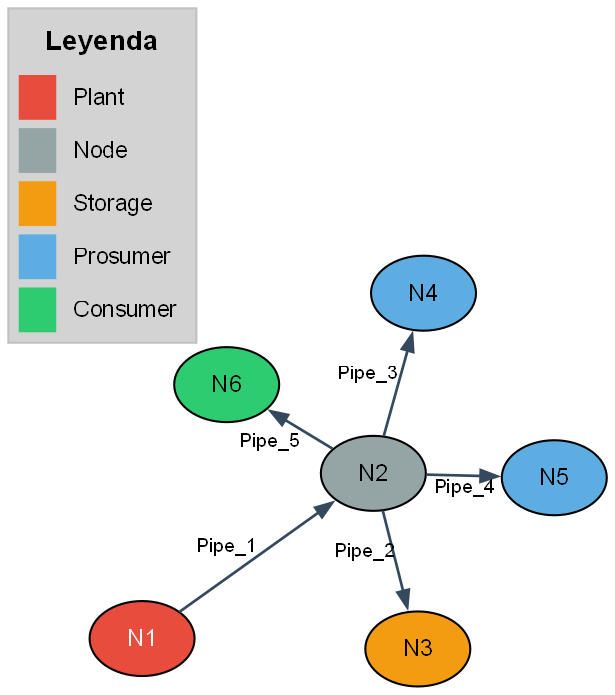

In [195]:
Image("network.png") 